In [1]:
import pandas as pd
df = pd.read_csv("Online_Retail_Cleaned.csv")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(532132, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532132 entries, 0 to 532131
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    532132 non-null  object 
 1   StockCode    532132 non-null  object 
 2   Description  532132 non-null  object 
 3   Quantity     532132 non-null  int64  
 4   InvoiceDate  532132 non-null  object 
 5   UnitPrice    532132 non-null  float64
 6   CustomerID   399932 non-null  float64
 7   Country      532132 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.5+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,532132.000000,532132.000000,399932.000000
mean,10.016107,3.346930,15288.334672
std,217.681087,6.960386,1710.506855
min,-80995.000000,0.000000,12346.000000
25%,1.000000,1.250000,13959.000000
50%,3.000000,2.080000,15150.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,1867.860000,18287.000000


In [7]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [8]:
StandardScaler()

StandardScaler()

In [10]:
K = 2, 3, 4, 5, 6, 7, 8

In [11]:
KMeans(n_clusters=2, random_state=42, n_init=20)

KMeans(n_clusters=2, n_init=20, random_state=42)

In [34]:
print("Number of customers:", rfm.shape[0])

Number of customers: 4335


In [35]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove missing Customer IDs
df = df.dropna(subset=["CustomerID"])

# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Calculate total transaction value
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Set reference date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("RFM table created successfully!")
print("Number of customers:", rfm.shape[0])

rfm.head()

RFM table created successfully!
Number of customers: 4335


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1437.24
3,12349.0,19,1,1457.55
4,12350.0,310,1,294.40


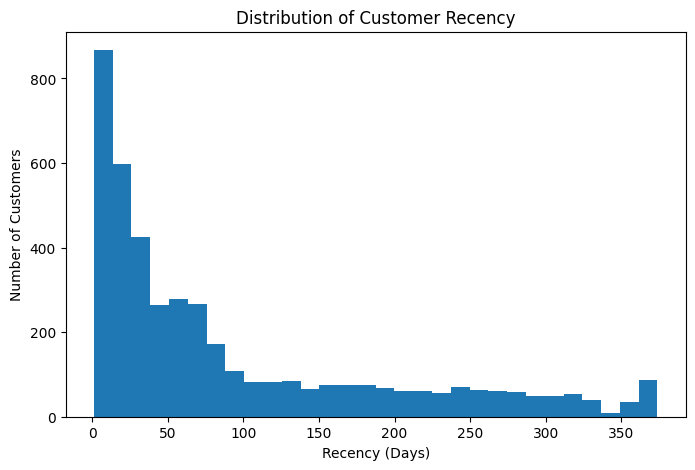

In [36]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Recency"], bins=30)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

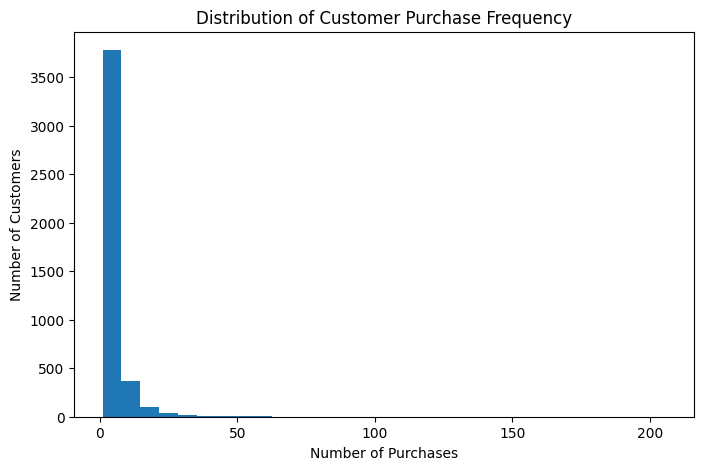

In [18]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Frequency"], bins=30)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
features = ["Recency", "Frequency", "Monetary"]

# Log transformation
X_log = np.log1p(rfm[features])

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Data standardized successfully.")

Data standardized successfully.


In [20]:
inertia = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

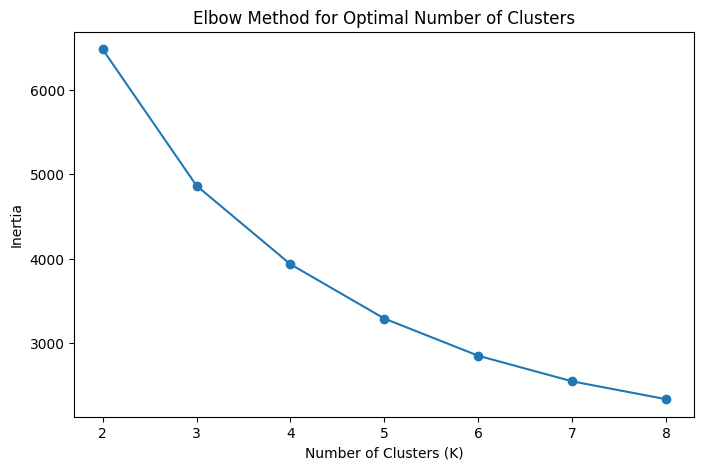

In [21]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.show()

In [22]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

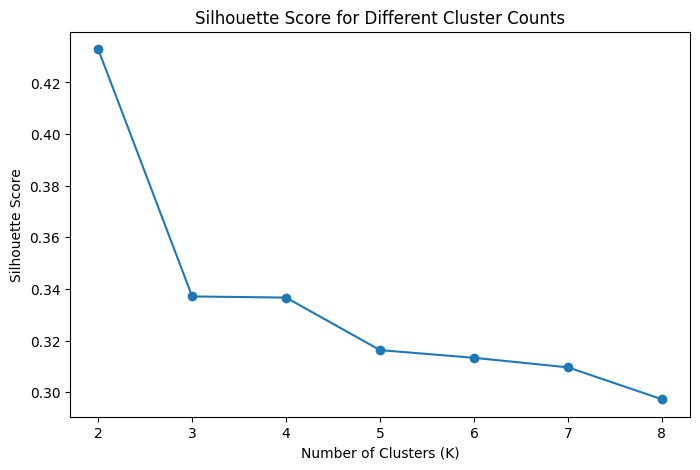

In [23]:
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker="o")

plt.title("Silhouette Score for Different Cluster Counts")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(K_range)

plt.show()

In [24]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k} → Silhouette Score = {score:.4f}")

K = 2 → Silhouette Score = 0.4329
K = 3 → Silhouette Score = 0.3371
K = 4 → Silhouette Score = 0.3367
K = 5 → Silhouette Score = 0.3163
K = 6 → Silhouette Score = 0.3134
K = 7 → Silhouette Score = 0.3097
K = 8 → Silhouette Score = 0.2973


In [25]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1437.24,0
3,12349.0,19,1,1457.55,1
4,12350.0,310,1,294.40,1


In [26]:
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,25.805288,8.40024,4463.329496
1,134.388618,1.66155,493.110581


In [27]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,25.81,8.40,4463.33
1,134.39,1.66,493.11


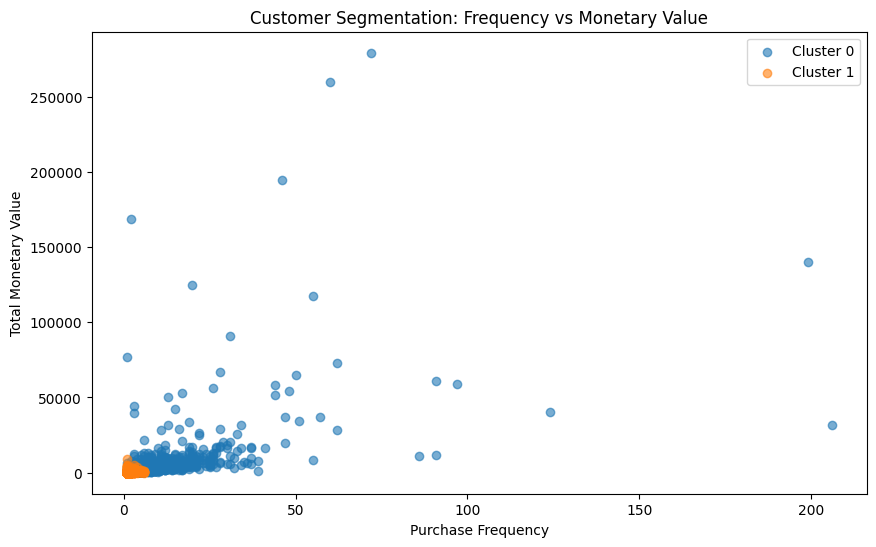

In [28]:
plt.figure(figsize=(10,6))

for cluster in sorted(rfm["Cluster"].unique()):

    cluster_data = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("Customer Segmentation: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Monetary Value")
plt.legend()

plt.show()

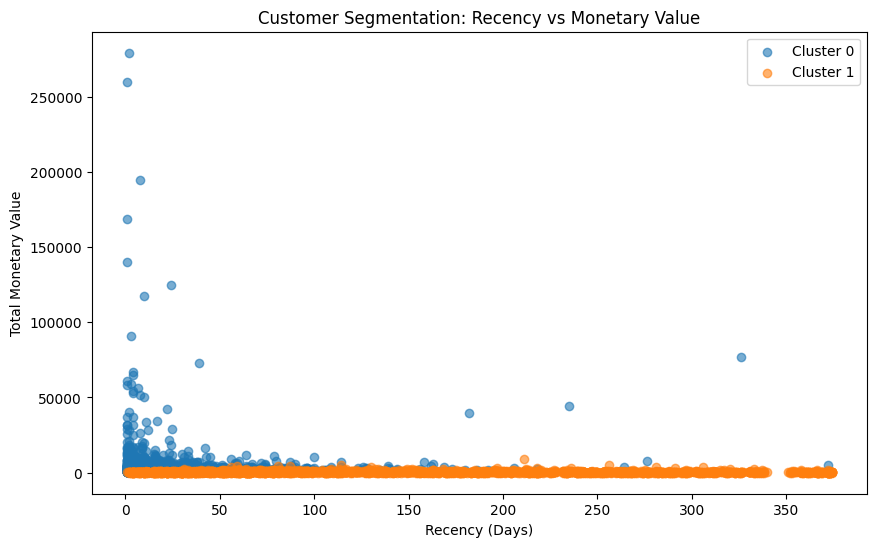

In [29]:
plt.figure(figsize=(10,6))

for cluster in sorted(rfm["Cluster"].unique()):

    cluster_data = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Recency"],
        cluster_data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("Customer Segmentation: Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Total Monetary Value")
plt.legend()

plt.show()

In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

rfm["PCA1"] = X_pca[:, 0]
rfm["PCA2"] = X_pca[:, 1]

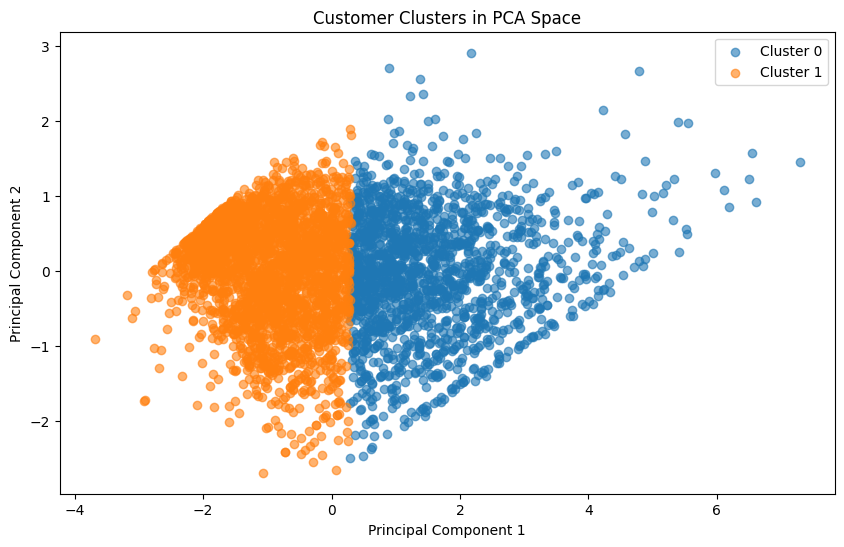

In [31]:
plt.figure(figsize=(10,6))

for cluster in sorted(rfm["Cluster"].unique()):

    cluster_data = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("Customer Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

In [32]:
rfm.to_csv("Customer_RFM_Clusters.csv", index=False)

print("Clustered customer dataset saved successfully!")

Clustered customer dataset saved successfully!
